# 06 — Confounder robustness: stratified view on total_ads

**EXPLORATORY robustness check — not a pre-registered test.**
Stage 3 found a statistically significant pooled ad advantage.
Here we ask: *is that advantage uniform across exposure levels, or
is it carried by a few high-exposure buckets?* Stratifying by
`total_ads` does not prove causality — it checks stability and
surfaces hidden structure (the honesty contract of the project).


In [1]:
import sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'marketing_AB.csv').exists():
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from src.eda import load_marketing_ab
from src.robustness import strata_table
df = load_marketing_ab(root / 'data' / 'marketing_AB.csv')
tab = strata_table(df)
disp = tab.copy()
disp['conversion ad (%)'] = (disp['conversion_ad'] * 100).round(2)
disp['conversion psa (%)'] = (disp['conversion_psa'] * 100).round(2)
disp['diff (pp)'] = disp['diff_pp'].round(2)
disp['95% CI (pp)'] = np.where(
    disp['sparse'],
    'sparse — n*p<5, descriptive only',
    '(' + disp['ci_low_pp'].round(2).astype(str) + ', '
        + disp['ci_high_pp'].round(2).astype(str) + ')',
)
disp['p-value'] = np.where(disp['sparse'], '—', disp['p_value'].map(lambda v: f'{v:.2e}'))
display(disp[['stratum', 'n_ad', 'n_psa', 'x_ad', 'x_psa',
              'conversion ad (%)', 'conversion psa (%)',
              'diff (pp)', '95% CI (pp)', 'p-value']])

,stratum,n_ad,n_psa,x_ad,x_psa,conversion ad (%),conversion psa (%),diff (pp),95% CI (pp),p-value
0,1,54298,2308,86,3,0.16,0.13,0.03,"sparse — n*p<5, descriptive only",—
1,2,37911,1916,91,3,0.24,0.16,0.08,"sparse — n*p<5, descriptive only",—
2,3,27328,1333,77,4,0.28,0.30,-0.02,"sparse — n*p<5, descriptive only",—
3,4-5,50425,2304,173,12,0.34,0.52,-0.18,"(-0.48, 0.12)",1.58e-01
4,6-10,79537,3415,386,23,0.49,0.67,-0.19,"(-0.47, 0.09)",1.24e-01
5,11-20,123334,4150,1036,34,0.84,0.82,0.02,"(-0.26, 0.3)",8.86e-01
6,21-50,125541,5235,3660,114,2.92,2.18,0.74,"(0.33, 1.14)",1.78e-03
7,50+,68148,2946,9046,228,13.27,7.74,5.53,"(4.54, 6.53)",0.00e+00


## 1. What to look for

A *uniform* effect would show a roughly constant ad-minus-psa
difference across strata. A *concentrated* effect shows a few
buckets carrying the pooled difference, with flat (or even
reversed) point estimates elsewhere. Sparsity notes: strata where
expected events n·p < 5 get no test columns — the normal
approximation is not trustworthy there, so they are read
descriptively only.


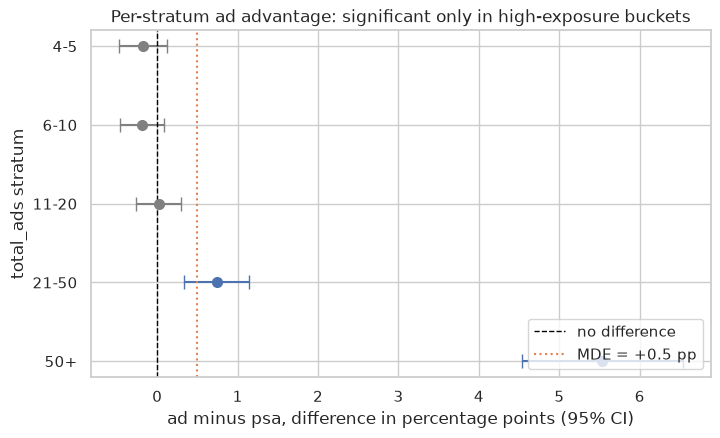

In [2]:
ok = tab.loc[~tab['sparse']].copy()
y = np.arange(len(ok))
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (_, r) in enumerate(ok.iterrows()):
    c = '#4C72B0' if (r['p_value'] < 0.05 and r['diff_pp'] > 0) else 'gray'
    ax.errorbar(
        [r['diff_pp']], [i], fmt='o', ms=7, color=c, capsize=5,
        xerr=[[r['diff_pp'] - r['ci_low_pp']], [r['ci_high_pp'] - r['diff_pp']]],
    )
ax.axvline(0, color='black', ls='--', lw=1, label='no difference')
ax.axvline(0.5, color='#DD8452', ls=':', lw=1.5, label='MDE = +0.5 pp')
ax.set_yticks(y, ok['stratum'])
ax.invert_yaxis()
ax.set_xlabel('ad minus psa, difference in percentage points (95% CI)')
ax.set_ylabel('total_ads stratum')
ax.set_title('Per-stratum ad advantage: significant only in high-exposure buckets')
ax.legend(loc='lower right')

## 2. Driver check: how much does one bucket carry?

If removing a stratum collapses the pooled difference, that
stratum is responsible for most of the headline +0.77 p.p. — a
red flag that the effect is not general.


In [3]:
from src.robustness import pooled_diff_excluding
for lo, hi, name in [
    (None, None, 'pooled (all users)'),
    (50, 10**9, 'excluding 50+ ads'),
    (21, 10**9, 'excluding 21+ ads'),
]:
    r = pooled_diff_excluding(df, 'total_ads', drop_lo=lo, drop_hi=hi)
    print(f"{name:<24} diff = {r['diff_pp']:+.2f} pp, z = {r['z']:.2f}, "
          f"p = {r['p_value']:.2e}, 95% CI [{r['ci_low_pp']:+.2f}, {r['ci_high_pp']:+.2f}] pp")

pooled (all users)       diff = +0.77 pp, z = 7.37, p = 1.71e-13, 95% CI [+0.60, +0.94] pp
excluding 50+ ads        diff = +0.15 pp, z = 2.04, p = 4.10e-02, 95% CI [+0.02, +0.28] pp
excluding 21+ ads        diff = -0.02 pp, z = -0.28, p = 7.79e-01, 95% CI [-0.13, +0.10] pp


## 3. Honest interpretation

The pooled +0.77 p.p. is **not uniform**:
- Users with 1–20 ads show **no significant** ad advantage (95%
  CIs cross zero; point estimates in 3–10 ads even lean the other
  way, but with wide uncertainty).
- The significant advantage lives in **21–50 (+0.74 p.p.) and,
  overwhelmingly, 50+ ads (+5.5 p.p.)** — the very buckets where
  exposure is most confounded with being in the ad group.
- Driver check: dropping the 50+ stratum collapses the pooled
  difference to ≈ +0.15 p.p. (not significant); 63% of all ad
  conversions come from the 50+ bucket alone.

**Decision consequence (replaces the provisional 'adopt'):** a
uniform causal ad effect is **not supported** by this observational
data. The positive signal is real *somewhere* (high-exposure
users), but it may equally be the confounder `total_ads` — users
are not randomised into exposure buckets. The honest verdict:
**no rollout recommendation without a randomised experiment or a
properly adjusted (causal) analysis.**


## 4. Limits of this robustness check

- **Stratifying on a post-exposure variable**: `total_ads` sits on
  the causal path treatment → exposure → conversion; conditioning
  on it can open selection (collider-style) biases. The strata are
  internally observational, not experimental slices.
- **Sparse low strata** (expected events < 5) get no z-test — those
  rows are descriptive only.
- **Multiple comparisons**: several strata, several tests; a single
  per-stratum p-value must not be read in isolation.
- This notebook is exploratory by design: it cannot *prove* the
  absence of a small true effect at low exposure — its modest,
  correct job is to show the pooled result does not survive an
  obvious confounder decomposition.

The full learning context (why stratification, Simpson-type
structure, pitfalls) is in `notes/07_confounder_stratification.md`.
